In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías cargadas correctamente")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")

Librerías cargadas correctamente
Pandas: 2.2.3
NumPy: 2.1.1


In [36]:
import os

archivos = {
      2023: '../data/raw/entradas_salidas/Datos_abiertos_ ESI_2023/esi2023.csv',
      2024: '../data/raw/entradas_salidas/Datos_abiertos_ ESI_2024/esi_2024.csv',
      2025: '../data/raw/entradas_salidas/Datos_abiertos_ESI_2025/ESI2025.csv',
}
for anio, ruta in archivos.items():
     existe = os.path.exists(ruta)
     tam = os.path.getsize(ruta) / 1024 / 1024
     print(f"{anio}: {'✓' if existe else '✗'}  ({tam:.0f} MB)  {ruta}")

2023: ✓  (1978 MB)  ../data/raw/entradas_salidas/Datos_abiertos_ ESI_2023/esi2023.csv
2024: ✓  (1951 MB)  ../data/raw/entradas_salidas/Datos_abiertos_ ESI_2024/esi_2024.csv
2025: ✓  (1983 MB)  ../data/raw/entradas_salidas/Datos_abiertos_ESI_2025/ESI2025.csv


In [37]:
# columnas = ['tip_movi', 'tip_naci', 'anio_movi', 'mes_movi',
#              'sex_migr', 'nac_migr', 'cont_nac', 'via_tran',
#              'mot_viam', 'pro_jefm', 'edad']
# dfs = []
# for anio, ruta in archivos.items():
#      print(f"Cargando {anio}...")
#      df_temp = pd.read_csv(
#          ruta,
#          usecols=lambda c: c.strip('"').strip(';') in columnas,
#          encoding='utf-8',
#          low_memory=False,
#          sep=';' if anio == 2022 else ','
#      )
#      df_temp.columns = [c.strip('"').strip(';') for c in df_temp.columns]
#      dfs.append(df_temp)
#      print(f"  {len(df_temp):,} registros cargados")
# df = pd.concat(dfs, ignore_index=True)
# print(f"\nTotal combinado: {len(df):,} registros")
# print(f"Memoria usada: {df.memory_usage(deep=True).sum() / 1024 / 1024:.0f} MB")

## Exploración con DuckDB

Los archivos ESI pesan ~2 GB cada uno (~6.2 millones de filas). Pandas no puede cargarlos todos en RAM.  
**DuckDB** los consulta directamente en disco con SQL, y solo trae a Pandas el resultado resumido.

In [38]:
import duckdb

con = duckdb.connect()

# Rutas relativas desde la carpeta notebooks/
ESI_2023 = "../data/raw/entradas_salidas/Datos_abiertos_ ESI_2023/esi2023.csv"
ESI_2024 = "../data/raw/entradas_salidas/Datos_abiertos_ ESI_2024/esi_2024.csv"
ESI_2025 = "../data/raw/entradas_salidas/Datos_abiertos_ESI_2025/ESI2025.csv"

print(f"DuckDB {duckdb.__version__} listo")

DuckDB 1.5.1 listo


### 1. Conteo y columnas por archivo

In [39]:
for anio, ruta in [("2023", ESI_2023), ("2024", ESI_2024), ("2025", ESI_2025)]:
    resultado = con.execute(f"SELECT COUNT(*) FROM read_csv_auto('{ruta}')").fetchone()
    cols = con.execute(f"DESCRIBE SELECT * FROM read_csv_auto('{ruta}') LIMIT 1").df()
    print(f"ESI {anio}: {resultado[0]:,} filas | {len(cols)} columnas")
    print(f"  Columnas: {list(cols['column_name'].values)}\n")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ESI 2023: 6,205,610 filas | 25 columnas
  Columnas: ['secuencial', 'tip_movi', 'tip_naci', 'anio_movi', 'mes_movi', 'dia_movi', 'sex_migr', 'nac_migr', 'subcont_nac', 'cont_nac', 'via_tran', 'mot_viam', 'pais_prod', 'subcont_prod', 'cont_prod', 'lug_prod', 'pais_res', 'subcont_res', 'cont_res', 'jef_migr', 'pro_jefm', 'can_jefm', 'cla_migr', 'ocu_migr', 'edad']



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ESI 2024: 6,153,591 filas | 25 columnas
  Columnas: ['id_secuencial', 'tip_movi', 'tip_naci', 'anio_movi', 'mes_movi', 'dia_movi', 'sex_migr', 'nac_migr', 'subcont_nac', 'cont_nac', 'via_tran', 'mot_viam', 'pais_prod', 'subcont_prod', 'cont_prod', 'lug_prod', 'pais_res', 'subcont_res', 'cont_res', 'jef_migr', 'pro_jefm', 'can_jefm', 'cla_migr', 'ocu_migr', 'edad']



FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

ESI 2025: 6,265,521 filas | 25 columnas
  Columnas: ['id_secuencial', 'tip_movi', 'tip_naci', 'anio_movi', 'mes_movi', 'dia_movi', 'sex_migr', 'nac_migr', 'subcont_nac', 'cont_nac', 'via_tran', 'mot_viam', 'pais_prod', 'subcont_prod', 'cont_prod', 'lug_prod', 'pais_res', 'subcont_res', 'cont_res', 'jef_migr', 'pro_jefm', 'can_jefm', 'ocu_migr', 'edad', 'cla_migr']



### 2. Vista previa de los datos (primeras 5 filas)

In [40]:
con.execute(f"""
    SELECT tip_movi, tip_naci, anio_movi, mes_movi, sex_migr,
           nac_migr, cont_nac, via_tran, mot_viam, pro_jefm, edad
    FROM read_csv_auto('{ESI_2023}')
    LIMIT 5
""").df()

,tip_movi,tip_naci,anio_movi,mes_movi,sex_migr,nac_migr,cont_nac,via_tran,mot_viam,pro_jefm,edad
0,Salida,Extranjero,2023,Abril,Hombre,Italia,Europa,Vía Aérea,Turismo,Guayas,13
1,Salida,Ecuatoriano,2023,Agosto,Hombre,Ecuador,América,Vía Aérea,Turismo,Guayas,30
2,Salida,Ecuatoriano,2023,Febrero,Hombre,Ecuador,América,Vía Aérea,Turismo,Pichincha,18
3,Entrada,Ecuatoriano,2023,Diciembre,Hombre,Ecuador,América,Vía Aérea,Turismo,Pichincha,63
4,Salida,Ecuatoriano,2023,Mayo,Mujer,Ecuador,América,Vía Aérea,Turismo,Guayas,13


### 3. Entradas vs Salidas por año (los 3 datasets combinados)

In [41]:
df_resumen = con.execute(f"""
    SELECT anio_movi, tip_movi, COUNT(*) as total
    FROM (
        SELECT anio_movi, tip_movi FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT anio_movi, tip_movi FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT anio_movi, tip_movi FROM read_csv_auto('{ESI_2025}')
    )
    GROUP BY anio_movi, tip_movi
    ORDER BY anio_movi, tip_movi
""").df()

df_resumen["total_millones"] = (df_resumen["total"] / 1_000_000).round(2)
print(df_resumen.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

 anio_movi tip_movi   total  total_millones
      2023  Entrada 3069447            3.07
      2023   Salida 3136163            3.14
      2024  Entrada 3008163            3.01
      2024   Salida 3145428            3.15
      2025  Entrada 3126192            3.13
      2025   Salida 3139329            3.14


### 4. Estacionalidad: entradas internacionales por mes (2023–2025)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

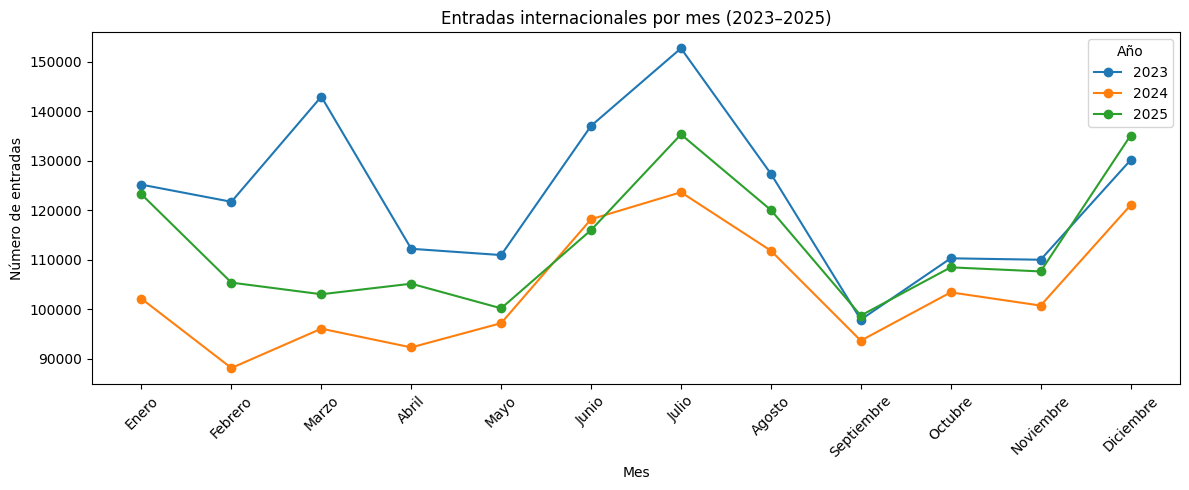

In [42]:
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

df_estac = con.execute(f"""
    SELECT anio_movi AS anio, mes_movi AS mes, COUNT(*) AS total
    FROM (
        SELECT anio_movi, mes_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT anio_movi, mes_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT anio_movi, mes_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2025}')
    )
    WHERE tip_movi = 'Entrada' AND tip_naci = 'Extranjero'
    GROUP BY anio_movi, mes_movi
    ORDER BY anio_movi
""").df()

df_estac["mes"] = pd.Categorical(df_estac["mes"], categories=orden_meses, ordered=True)
df_estac = df_estac.sort_values(["anio", "mes"])

fig, ax = plt.subplots(figsize=(12, 5))
for anio, grupo in df_estac.groupby("anio"):
    ax.plot(grupo["mes"], grupo["total"], marker="o", label=str(anio))

ax.set_title("Entradas internacionales por mes (2023–2025)")
ax.set_xlabel("Mes")
ax.set_ylabel("Número de entradas")
ax.legend(title="Año")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### 5. Top 15 paisses de origen (turistas extranjeros entrando a Ecuador)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

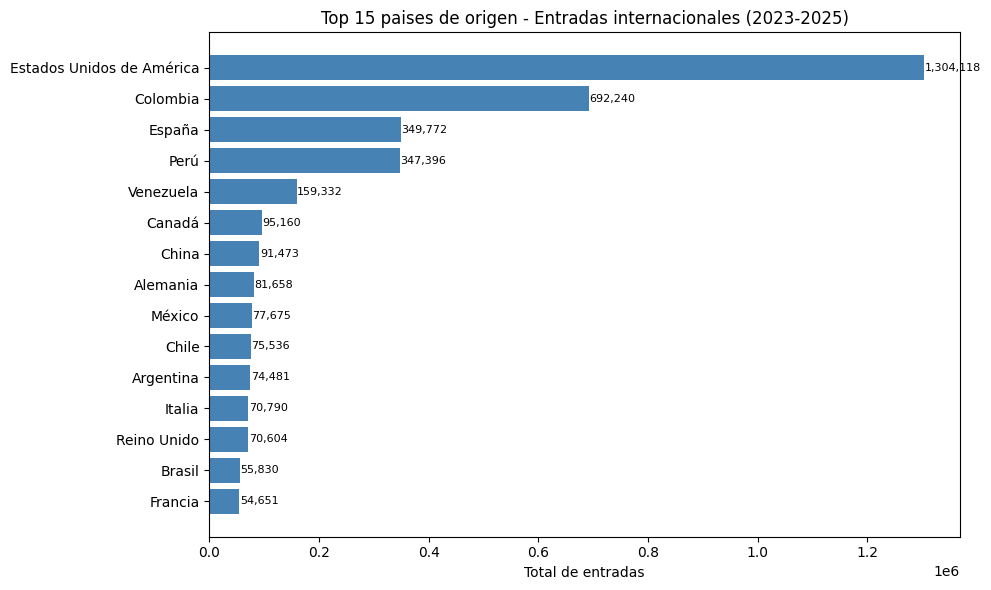

                     pais   total
Estados Unidos de América 1304118
                 Colombia  692240
                   España  349772
                     Perú  347396
                Venezuela  159332
                   Canadá   95160
                    China   91473
                 Alemania   81658
                   México   77675
                    Chile   75536
                Argentina   74481
                   Italia   70790
              Reino Unido   70604
                   Brasil   55830
                  Francia   54651


In [43]:
df_paises = con.execute(f"""
    SELECT nac_migr AS pais, COUNT(*) AS total
    FROM (
        SELECT nac_migr, tip_movi, tip_naci FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT nac_migr, tip_movi, tip_naci FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT nac_migr, tip_movi, tip_naci FROM read_csv_auto('{ESI_2025}')
    )
    WHERE tip_movi = 'Entrada' AND tip_naci = 'Extranjero'
    GROUP BY nac_migr
    ORDER BY total DESC
    LIMIT 15
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_paises['pais'][::-1], df_paises['total'][::-1], color='steelblue')
ax.set_title('Top 15 paises de origen - Entradas internacionales (2023-2025)')
ax.set_xlabel('Total de entradas')
for i, (val, pais) in enumerate(zip(df_paises['total'][::-1], df_paises['pais'][::-1])):
    ax.text(val + 1000, i, f'{val:,}', va='center', fontsize=8)
plt.tight_layout()
plt.show()
print(df_paises.to_string(index=False))

### 6. Motivos de viaje (entradas extranjeras por a�o)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

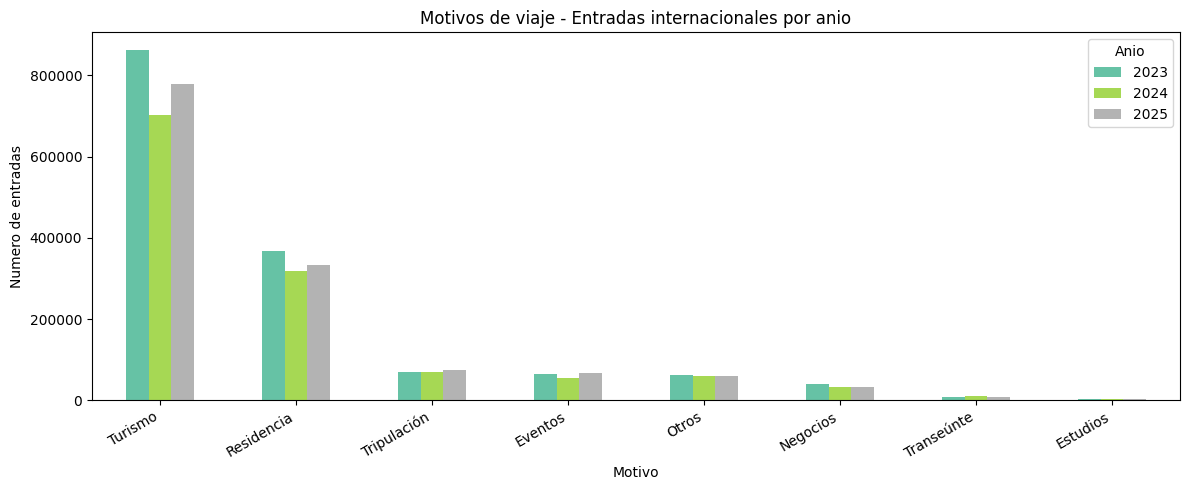

anio           2023    2024    2025
motivo                             
Turismo      863161  703110  778483
Residencia   368243  317365  333212
Tripulación   70254   69803   75110
Eventos       64028   53865   67616
Otros         61999   58887   60228
Negocios      40691   32089   32813
Transeúnte     6946   10913    8283
Estudios       2677    1904    2128


In [44]:
df_motivos = con.execute(f"""
    SELECT mot_viam AS motivo, anio_movi AS anio, COUNT(*) AS total
    FROM (
        SELECT mot_viam, anio_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT mot_viam, anio_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT mot_viam, anio_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2025}')
    )
    WHERE tip_movi = 'Entrada' AND tip_naci = 'Extranjero'
    GROUP BY mot_viam, anio_movi
    ORDER BY anio_movi, total DESC
""").df()

pivot = df_motivos.pivot(index='motivo', columns='anio', values='total').fillna(0)
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

pivot.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Motivos de viaje - Entradas internacionales por anio')
plt.xlabel('Motivo')
plt.ylabel('Numero de entradas')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Anio')
plt.tight_layout()
plt.show()
print(pivot.to_string())

### 7. Principales puntos de entrada al pa�s

In [ ]:
df_puntos = con.execute(f"""
    SELECT lug_prod AS punto_entrada, COUNT(*) AS total
    FROM (
        SELECT lug_prod, tip_movi, tip_naci FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT lug_prod, tip_movi, tip_naci FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT lug_prod, tip_movi, tip_naci FROM read_csv_auto('{ESI_2025}')
    )
    WHERE tip_movi = 'Entrada' AND tip_naci = 'Extranjero'
    GROUP BY lug_prod
    ORDER BY total DESC
    LIMIT 12
""").df()

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(df_puntos['punto_entrada'][::-1], df_puntos['total'][::-1], color='coral')
ax.set_title('Top 12 puntos de entrada - Turistas extranjeros (2023-2025)')
ax.set_xlabel('Total de entradas')
plt.tight_layout()
plt.show()
print(df_puntos.to_string(index=False))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

### 8. Correlaci�n: Homicidios vs llegadas internacionales

Cruce de la tasa de homicidios (Banco Mundial) con entradas anuales de turistas extranjeros para evaluar si el deterioro de seguridad en Ecuador (2022-2024) correlaciona con la ca�da en llegadas.

In [ ]:
import zipfile

# Homicidios Banco Mundial
zip_seg = '../data/raw/seguridad/API_VC.IHR.PSRC.P5_DS2_es_csv_v2_8348.zip'
csv_seg = 'API_VC.IHR.PSRC.P5_DS2_es_csv_v2_8348.csv'
with zipfile.ZipFile(zip_seg) as z:
    with z.open(csv_seg) as f:
        raw_seg = pd.read_csv(f, skiprows=4, encoding='utf-8')
ecu_seg = raw_seg[raw_seg['Country Code'] == 'ECU'].copy()
years_hom = [str(y) for y in range(2010, 2025)]
ecu_hom = ecu_seg[['Country Name'] + years_hom].melt(
    id_vars='Country Name', var_name='anio', value_name='homicidios_x100k'
).dropna(subset=['homicidios_x100k'])
ecu_hom['anio'] = ecu_hom['anio'].astype(int)

# Llegadas Banco Mundial ST.INT.ARVL 2010-2022
zip_bm = '../data/raw/banco_mundial/API_ST.INT.ARVL_DS2_es_csv_v2_4967.zip'
with zipfile.ZipFile(zip_bm) as z:
    fname = [n for n in z.namelist() if n.endswith('.csv') and 'Metadata' not in n][0]
    with z.open(fname) as f:
        raw_bm = pd.read_csv(f, skiprows=4, encoding='utf-8')
ecu_bm = raw_bm[raw_bm['Country Code'] == 'ECU'].copy()
bm_years = [str(y) for y in range(2010, 2023)]
ecu_bm_long = ecu_bm[['Country Name'] + bm_years].melt(
    id_vars='Country Name', var_name='anio', value_name='llegadas'
).dropna(subset=['llegadas'])
ecu_bm_long['anio'] = ecu_bm_long['anio'].astype(int)

# Entradas ESI 2023-2025
df_esi_anio = con.execute(f"""
    SELECT anio_movi AS anio, COUNT(*) AS llegadas
    FROM (
        SELECT anio_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT anio_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT anio_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2025}')
    )
    WHERE tip_movi = 'Entrada' AND tip_naci = 'Extranjero'
    GROUP BY anio_movi ORDER BY anio_movi
""").df()

# Combinar fuentes de llegadas
df_llegadas = pd.concat([ecu_bm_long[['anio','llegadas']], df_esi_anio], ignore_index=True)
df_llegadas = df_llegadas.drop_duplicates(subset='anio', keep='last').sort_values('anio')

# Merge final
df_merge = ecu_hom[['anio','homicidios_x100k']].merge(df_llegadas, on='anio', how='inner')
print(df_merge.to_string(index=False))

# Grafico doble eje
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()
ax1.bar(df_merge['anio'], df_merge['llegadas'], color='steelblue', alpha=0.6, label='Llegadas internacionales')
ax2.plot(df_merge['anio'], df_merge['homicidios_x100k'], color='crimson', marker='o', linewidth=2, label='Homicidios x100k')
ax1.set_xlabel('Anio')
ax1.set_ylabel('Llegadas internacionales', color='steelblue')
ax2.set_ylabel('Homicidios por 100.000 hab.', color='crimson')
ax1.set_title('Ecuador: Llegadas internacionales vs Tasa de homicidios (2010-2024)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

corr = df_merge['llegadas'].corr(df_merge['homicidios_x100k'])
print(f'Correlacion de Pearson (llegadas vs homicidios): {corr:.3f}')

### 9. Heatmap: flujos internacionales por continente x mes (2023-2025)

In [ ]:
orden_meses = ['Enero','Febrero','Marzo','Abril','Mayo','Junio',
               'Julio','Agosto','Septiembre','Octubre','Noviembre','Diciembre']

df_heat = con.execute(f"""
    SELECT cont_nac AS continente, mes_movi AS mes, COUNT(*) AS total
    FROM (
        SELECT cont_nac, mes_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2023}')
        UNION ALL
        SELECT cont_nac, mes_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2024}')
        UNION ALL
        SELECT cont_nac, mes_movi, tip_movi, tip_naci FROM read_csv_auto('{ESI_2025}')
    )
    WHERE tip_movi = 'Entrada' AND tip_naci = 'Extranjero'
    GROUP BY cont_nac, mes_movi
""").df()

df_heat['mes'] = pd.Categorical(df_heat['mes'], categories=orden_meses, ordered=True)
pivot_heat = df_heat.pivot_table(index='continente', columns='mes', values='total', aggfunc='sum').fillna(0)
pivot_heat = pivot_heat[orden_meses]

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_heat, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Entradas'})
ax.set_title('Heatmap: Entradas internacionales por continente x mes (2023-2025)')
ax.set_xlabel('Mes')
ax.set_ylabel('Continente de origen')
plt.tight_layout()
plt.show()